In [1]:
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

# import some common libraries
import numpy as np
import os, json, cv2, random, importlib
import matplotlib.pyplot as plt

# import some common detectron2 utilities
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog
import random
import cv2
import matplotlib.pyplot as plt
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.config import get_cfg

# import our functions 
os.chdir("../../util/preprocessing")
import tumor_dataset

importlib.reload(tumor_dataset)
from tumor_dataset import Dataset

In [2]:
from detectron2.data.datasets import register_coco_instances
d = Dataset(data_path="../../data/raw_data/useable_data")
d.convert_binary_to_coco()
d.register_instances(rgb=True)

Init Dataset
Created 181 annotations for images in folder: /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgb/train/masks
Created 24 annotations for images in folder: /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgb/val/masks
Created 36 annotations for images in folder: /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgb/test/masks
Created 181 annotations for images in folder: /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/depth/train/masks
Created 24 annotations for images in folder: /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/depth/val/masks
Created 36 annotations for images in folder: /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/depth/test/masks
Created 181 annotations for images in folder: /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgd/train/masks
Created 24 annotations for images in folder: /projects/PUCHALLA/LLP2024/tumor-segmentation/data

In [3]:
train_metadata = MetadataCatalog.get("my_dataset_train")
train_dataset_dicts = DatasetCatalog.get("my_dataset_train")

val_metadata = MetadataCatalog.get("my_dataset_val")
val_dataset_dicts = DatasetCatalog.get("my_dataset_val")

test_metadata = MetadataCatalog.get("my_dataset_test")
test_dataset_dicts = DatasetCatalog.get("my_dataset_test")

[07/15 17:58:42 d2.data.datasets.coco]: Loaded 180 images in COCO format from /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgb/train/images/train.json
[07/15 17:58:42 d2.data.datasets.coco]: Loaded 24 images in COCO format from /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgb/val/images/val.json
[07/15 17:58:42 d2.data.datasets.coco]: Loaded 36 images in COCO format from /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgb/test/images/test.json


Image file: /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgb/val/images/val_11.jpg
Mask file: ../../data/processed_data/val/masks/Tumor/val_11.png
Failed to load mask: ../../data/processed_data/val/masks/Tumor/val_11.png


[ WARN:0@3.004] global loadsave.cpp:241 findDecoder imread_('../../data/processed_data/val/masks/Tumor/val_11.png'): can't open/read file: check file path/integrity


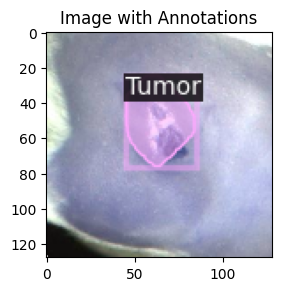

In [4]:
mask_folder = "../../data/processed_data/val/masks/Tumor"  # Update with your binary mask folder path

for d in random.sample(val_dataset_dicts, 1):
    # Load the image
    img = cv2.imread(d["file_name"])

    print(f"Image file: {d['file_name']}")
    
    # Check if the image was successfully loaded
    if img is None:
        print(f"Failed to load image: {d['file_name']}")
        continue

    # Visualize the image with annotations
    visualizer = Visualizer(img[:, :, ::-1], metadata=val_metadata, scale=0.5)
    vis = visualizer.draw_dataset_dict(d)

    # Display the annotated image
    plt.subplot(1, 2, 1)  # 1 row, 2 columns, first subplot
    plt.imshow(vis.get_image()[:, :, ::-1])
    plt.title("Image with Annotations")

    # Load the corresponding binary mask
    image_base_name = os.path.basename(d["file_name"]).split(".")[0]  # Get base name of the image
    mask_path = os.path.join(mask_folder, f"{image_base_name}.png")  # Assuming masks have .jpg extension

    print(f"Mask file: {mask_path}")
    
    # Load the binary mask
    mask_img = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    # Check if the mask was successfully loaded
    if mask_img is None:
        print(f"Failed to load mask: {mask_path}")
        continue

    # Display the binary mask
    plt.subplot(1, 2, 2)  # 1 row, 2 columns, second subplot
    plt.imshow(mask_img, cmap="gray")
    plt.title("Binary Mask")

    plt.show()  # Display the images side by side

now essentially what we want to do here is create a sub class of the default trainer so we can implement image augmentations.
These augmentations were defined by the medsam2 paper, seemed good enough to use here 

In [5]:
from TrainerClass import Trainer

In [6]:
from detectron2.engine import DefaultTrainer

cfg = get_cfg()
cfg.OUTPUT_DIR = '../../models/detectron2_test/test3'
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg.DATASETS.TRAIN = ("my_dataset_train",)
cfg.DATASETS.TEST = ("my_dataset_val",)
cfg.DATALOADER.NUM_WORKERS = 1
cfg.DATALOADER.FILTER_EMPTY_ANNOTATIONS = False # this is for our "no tumor" examples 
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")  # Let training initialize from model zoo
cfg.SOLVER.IMS_PER_BATCH = 2  # This is the real "batch size" commonly known to deep learning people
cfg.SOLVER.BASE_LR = 0.00025  # pick a good LR
cfg.SOLVER.MAX_ITER = 1000    
cfg.SOLVER.STEPS = []        
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 512   # The "RoIHead batch size". 128 is faster, and good enough for this toy dataset (default: 512)
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1  
# NOTE: this config means the number of classes, but a few popular unofficial tutorials incorrect uses num_classes+1 here.

os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
trainer = Trainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()

[07/15 17:58:43 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

Skip loading parameter 'roi_heads.box_predictor.cls_score.weight' to the model due to incompatible shapes: (81, 1024) in the checkpoint but (2, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.cls_score.bias' to the model due to incompatible shapes: (81,) in the checkpoint but (2,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.weight' to the model due to incompatible shapes: (320, 1024) in the checkpoint but (4, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.bias' to the model due to incompatible shapes: (320,) in the checkpoint but (4,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.mask_head.predictor.weight' to the model due to incompatible shapes: (80, 256, 1, 1) in the checkpoint but (1, 256, 1, 1) in

[07/15 17:58:43 d2.engine.train_loop]: Starting training from iteration 0


/home/am0532/.conda/envs/tumor-env/lib/python3.12/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4314.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Hook running at iteration 0
ERROR [07/15 17:58:44 d2.engine.train_loop]: Exception during training:
Traceback (most recent call last):
  File "/home/am0532/.conda/envs/tumor-env/lib/python3.12/site-packages/detectron2/engine/train_loop.py", line 156, in train
    self.after_step()
  File "/home/am0532/.conda/envs/tumor-env/lib/python3.12/site-packages/detectron2/engine/train_loop.py", line 190, in after_step
    h.after_step()
  File "/projects/PUCHALLA/LLP2024/tumor-segmentation/src/Detectron2/TrainerClass.py", line 105, in after_step
    if key in storage._history and len(storage._history[key]) > 0:
                                   ^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: object of type 'HistoryBuffer' has no len()
[07/15 17:58:44 d2.engine.hooks]: Total training time: 0:00:00 (0:00:00 on hooks)
[07/15 17:58:44 d2.utils.events]:  iter: 0  total_loss: 1.291  loss_cls: 0.4632  loss_box_reg: 0.03862  loss_mask: 0.6935  loss_rpn_cls: 0.0842  loss_rpn_loc: 0.01177    data_time: 0.0645  las

TypeError: object of type 'HistoryBuffer' has no len()

In [8]:
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")  # path to the model we just trained
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5   # set a custom testing threshold
predictor = DefaultPredictor(cfg)

[07/15 16:46:06 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ../../models/detectron2/model_final.pth ...


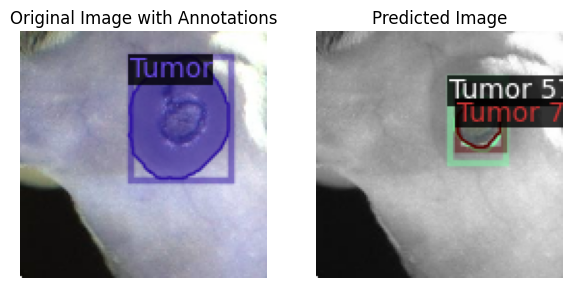

In [14]:
# Function to display the original image with annotations and the predicted image
def display_original_and_prediction_with_annotations(val_dataset_dicts, predictor, val_metadata):
    for d in random.sample(val_dataset_dicts, 1):  # Select number of images for display
        im = cv2.imread(d["file_name"])
        outputs = predictor(im)
        
        # Create a visualizer object for the original image with annotations
        v_gt = Visualizer(im[:, :, ::-1],
                          metadata=val_metadata,
                          scale=0.5
        )
        out_gt = v_gt.draw_dataset_dict(d)
        
        # Create a visualizer object for the predicted image
        v_pred = Visualizer(im[:, :, ::-1],
                            metadata=val_metadata,
                            scale=0.5,
                            instance_mode=ColorMode.IMAGE_BW  # Remove the colors of unsegmented pixels
        )
        out_pred = v_pred.draw_instance_predictions(outputs["instances"].to("cpu"))
        
        # Set up subplots
        fig, ax = plt.subplots(1, 2, figsize=(7,7))
        
        # Display the original image with annotations
        ax[0].imshow(out_gt.get_image()[:, :, ::-1])
        ax[0].set_title('Original Image with Annotations')
        
        # Display the predicted image
        ax[1].imshow(out_pred.get_image()[:, :, ::-1])
        ax[1].set_title('Predicted Image')

        for a in ax:
            a.axis("off")
        
        plt.show()

# Example usage
display_original_and_prediction_with_annotations(val_dataset_dicts, predictor, test_metadata)


In [15]:
def save_all_images(val_dataset_dicts, predictor, val_metadata, output_dir):
    
    #create image path if it doesnt exist 
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    for i, d in enumerate(val_dataset_dicts):

        im = cv2.imread(d["file_name"])
        outputs = predictor(im)
        
        v_gt = Visualizer(im[:, :, ::-1], metadata=val_metadata, scale=0.5)
        out_gt = v_gt.draw_dataset_dict(d)
        
        v_pred = Visualizer(im[:, :, ::-1], metadata=val_metadata, scale=0.5, instance_mode=ColorMode.IMAGE_BW)
        out_pred = v_pred.draw_instance_predictions(outputs["instances"].to("cpu"))
        
        fig, ax = plt.subplots(1, 2, figsize=(30, 30))

        ax[0].imshow(out_gt.get_image()[:, :, ::-1])
        ax[0].set_title('Image with Original Annotations', fontsize=24)
        ax[0].axis('off')
        
        # Display the predicted image
        ax[1].imshow(out_pred.get_image()[:, :, ::-1])
        ax[1].set_title('Images with Annotations produced by the model', fontsize=24)
        ax[1].axis('off')
        
        fig.savefig(os.path.join(output_dir, f"image_{i}.png"), bbox_inches="tight")
        plt.close(fig) 

In [16]:
save_all_images(test_dataset_dicts, predictor, test_metadata, './detectron2/images_rgb')